# La Liga predictor

## Objective

Create a Machine Learning model that predicts the outcome of La Liga football matches using historical data from 10 seasons (2016–2025).

**Expected output**: Probabilities for each class (Home win, Draw, Away win)


---
## 1. Data Dictionary

---
## 2. Configuration and data import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)


In [ ]:
# load all the CSV (temporadas 2016-2025)
data_path = Path('.')
seasons = range(2016, 2026)

dfs = []
for year in seasons:
    file_path = data_path / f'{year}.csv'
    if file_path.exists():
        df_temp = pd.read_csv(file_path)
        df_temp['Season'] = f'{year}/{year+1}'
        dfs.append(df_temp)
        print(f"Temporada {year}/{year+1}: {len(df_temp)} partidos cargados")
    else:
        print(f"Archivo {year}.csv no encontrado")

# Concatenar todos los DataFrames
df = pd.concat(dfs, ignore_index=True)
print(f"\nTotal of matches loaded: {len(df)}")

In [ ]:
df.head()

In [ ]:
# Verificar estructura del DataFrame
print("Columnas disponibles:")
print(df.columns.tolist())

In [ ]:
# Diccionario de renombrado de columnas
column_rename_mapping = {
    # Información básica del partido
    'Div': 'league_division',
    'Date': 'match_date',
    'Time': 'kick_off_time',
    'HomeTeam': 'home_team',
    'AwayTeam': 'away_team',
    'Season': 'season',

    # Resultados - Tiempo completo
    'FTHG': 'full_time_home_goals',
    'FTAG': 'full_time_away_goals',
    'FTR': 'full_time_result',

    # Resultados - Primer tiempo
    'HTHG': 'half_time_home_goals',
    'HTAG': 'half_time_away_goals',
    'HTR': 'half_time_result',

    # Estadísticas del partido
    'HS': 'home_shots',
    'AS': 'away_shots',
    'HST': 'home_shots_on_target',
    'AST': 'away_shots_on_target',
    'HC': 'home_corners',
    'AC': 'away_corners',
    'HF': 'home_fouls',
    'AF': 'away_fouls',
    'HY': 'home_yellow_cards',
    'AY': 'away_yellow_cards',
    'HR': 'home_red_cards',
    'AR': 'away_red_cards',

    # Bet365 - Cuotas pre-partido
    'B365H': 'bet365_home_win_odds',
    'B365D': 'bet365_draw_odds',
    'B365A': 'bet365_away_win_odds',
    'B365>2.5': 'bet365_over_2_5_goals',
    'B365<2.5': 'bet365_under_2_5_goals',

    # Bet365 - Cuotas de cierre
    'B365CH': 'bet365_closing_home_win_odds',
    'B365CD': 'bet365_closing_draw_odds',
    'B365CA': 'bet365_closing_away_win_odds',
    'B365C>2.5': 'bet365_closing_over_2_5_goals',
    'B365C<2.5': 'bet365_closing_under_2_5_goals',

    # Bet&Win - Cuotas pre-partido
    'BWH': 'betwin_home_win_odds',
    'BWD': 'betwin_draw_odds',
    'BWA': 'betwin_away_win_odds',

    # Bet&Win - Cuotas de cierre
    'BWCH': 'betwin_closing_home_win_odds',
    'BWCD': 'betwin_closing_draw_odds',
    'BWCA': 'betwin_closing_away_win_odds',

    # Interwetten - Cuotas pre-partido
    'IWH': 'interwetten_home_win_odds',
    'IWD': 'interwetten_draw_odds',
    'IWA': 'interwetten_away_win_odds',

    # Interwetten - Cuotas de cierre
    'IWCH': 'interwetten_closing_home_win_odds',
    'IWCD': 'interwetten_closing_draw_odds',
    'IWCA': 'interwetten_closing_away_win_odds',

    # Ladbrokes - Cuotas pre-partido
    'LBH': 'ladbrokes_home_win_odds',
    'LBD': 'ladbrokes_draw_odds',
    'LBA': 'ladbrokes_away_win_odds',

    # Ladbrokes - Cuotas de cierre
    'LBCH': 'ladbrokes_closing_home_win_odds',
    'LBCD': 'ladbrokes_closing_draw_odds',
    'LBCA': 'ladbrokes_closing_away_win_odds',

    # Pinnacle - Cuotas pre-partido
    'PSH': 'pinnacle_home_win_odds',
    'PSD': 'pinnacle_draw_odds',
    'PSA': 'pinnacle_away_win_odds',
    'P>2.5': 'pinnacle_over_2_5_goals',
    'P<2.5': 'pinnacle_under_2_5_goals',

    # Pinnacle - Cuotas de cierre
    'PSCH': 'pinnacle_closing_home_win_odds',
    'PSCD': 'pinnacle_closing_draw_odds',
    'PSCA': 'pinnacle_closing_away_win_odds',
    'PC>2.5': 'pinnacle_closing_over_2_5_goals',
    'PC<2.5': 'pinnacle_closing_under_2_5_goals',

    # William Hill - Cuotas pre-partido
    'WHH': 'william_hill_home_win_odds',
    'WHD': 'william_hill_draw_odds',
    'WHA': 'william_hill_away_win_odds',

    # William Hill - Cuotas de cierre
    'WHCH': 'william_hill_closing_home_win_odds',
    'WHCD': 'william_hill_closing_draw_odds',
    'WHCA': 'william_hill_closing_away_win_odds',

    # VC Bet / BetVictor - Cuotas pre-partido
    'VCH': 'vcbet_home_win_odds',
    'VCD': 'vcbet_draw_odds',
    'VCA': 'vcbet_away_win_odds',

    # VC Bet / BetVictor - Cuotas de cierre
    'VCCH': 'vcbet_closing_home_win_odds',
    'VCCD': 'vcbet_closing_draw_odds',
    'VCCA': 'vcbet_closing_away_win_odds',

    # BetBrain - Cuotas 1X2
    'Bb1X2': 'betbrain_num_bookmakers_match_odds',
    'BbMxH': 'betbrain_max_home_win_odds',
    'BbAvH': 'betbrain_avg_home_win_odds',
    'BbMxD': 'betbrain_max_draw_odds',
    'BbAvD': 'betbrain_avg_draw_odds',
    'BbMxA': 'betbrain_max_away_win_odds',
    'BbAvA': 'betbrain_avg_away_win_odds',

    # BetBrain - Over/Under 2.5
    'BbOU': 'betbrain_num_bookmakers_over_under',
    'BbMx>2.5': 'betbrain_max_over_2_5_goals',
    'BbAv>2.5': 'betbrain_avg_over_2_5_goals',
    'BbMx<2.5': 'betbrain_max_under_2_5_goals',
    'BbAv<2.5': 'betbrain_avg_under_2_5_goals',

    # Mercado - Máximos y promedios pre-partido
    'MaxH': 'market_max_home_win_odds',
    'MaxD': 'market_max_draw_odds',
    'MaxA': 'market_max_away_win_odds',
    'AvgH': 'market_avg_home_win_odds',
    'AvgD': 'market_avg_draw_odds',
    'AvgA': 'market_avg_away_win_odds',
    'Max>2.5': 'market_max_over_2_5_goals',
    'Max<2.5': 'market_max_under_2_5_goals',
    'Avg>2.5': 'market_avg_over_2_5_goals',
    'Avg<2.5': 'market_avg_under_2_5_goals',

    # Mercado - Máximos y promedios de cierre
    'MaxCH': 'market_closing_max_home_win_odds',
    'MaxCD': 'market_closing_max_draw_odds',
    'MaxCA': 'market_closing_max_away_win_odds',
    'AvgCH': 'market_closing_avg_home_win_odds',
    'AvgCD': 'market_closing_avg_draw_odds',
    'AvgCA': 'market_closing_avg_away_win_odds',
    'MaxC>2.5': 'market_closing_max_over_2_5_goals',
    'MaxC<2.5': 'market_closing_max_under_2_5_goals',
    'AvgC>2.5': 'market_closing_avg_over_2_5_goals',
    'AvgC<2.5': 'market_closing_avg_under_2_5_goals',

    # Betfair - Cuotas pre-partido
    'BFH': 'betfair_home_win_odds',
    'BFD': 'betfair_draw_odds',
    'BFA': 'betfair_away_win_odds',

    # Betfair - Cuotas de cierre
    'BFCH': 'betfair_closing_home_win_odds',
    'BFCD': 'betfair_closing_draw_odds',
    'BFCA': 'betfair_closing_away_win_odds',

    # 1XBet - Cuotas pre-partido
    '1XBH': 'onexbet_home_win_odds',
    '1XBD': 'onexbet_draw_odds',
    '1XBA': 'onexbet_away_win_odds',

    # 1XBet - Cuotas de cierre
    '1XBCH': 'onexbet_closing_home_win_odds',
    '1XBCD': 'onexbet_closing_draw_odds',
    '1XBCA': 'onexbet_closing_away_win_odds',

    # Betfair Exchange - Cuotas pre-partido
    'BFEH': 'betfair_exchange_home_win_odds',
    'BFED': 'betfair_exchange_draw_odds',
    'BFEA': 'betfair_exchange_away_win_odds',
    'BFE>2.5': 'betfair_exchange_over_2_5_goals',
    'BFE<2.5': 'betfair_exchange_under_2_5_goals',

    # Betfair Exchange - Cuotas de cierre
    'BFECH': 'betfair_exchange_closing_home_win_odds',
    'BFECD': 'betfair_exchange_closing_draw_odds',
    'BFECA': 'betfair_exchange_closing_away_win_odds',
    'BFEC>2.5': 'betfair_exchange_closing_over_2_5_goals',
    'BFEC<2.5': 'betfair_exchange_closing_under_2_5_goals',

    # Betfred - Cuotas pre-partido
    'BFDH': 'betfred_home_win_odds',
    'BFDD': 'betfred_draw_odds',
    'BFDA': 'betfred_away_win_odds',

    # Betfred - Cuotas de cierre
    'BFDCH': 'betfred_closing_home_win_odds',
    'BFDCD': 'betfred_closing_draw_odds',
    'BFDCA': 'betfred_closing_away_win_odds',

    # BetMGM - Cuotas pre-partido
    'BMGMH': 'betmgm_home_win_odds',
    'BMGMD': 'betmgm_draw_odds',
    'BMGMA': 'betmgm_away_win_odds',

    # BetMGM - Cuotas de cierre
    'BMGMCH': 'betmgm_closing_home_win_odds',
    'BMGMCD': 'betmgm_closing_draw_odds',
    'BMGMCA': 'betmgm_closing_away_win_odds',

    # BetVictor - Cuotas pre-partido
    'BVH': 'betvictor_home_win_odds',
    'BVD': 'betvictor_draw_odds',
    'BVA': 'betvictor_away_win_odds',

    # BetVictor - Cuotas de cierre
    'BVCH': 'betvictor_closing_home_win_odds',
    'BVCD': 'betvictor_closing_draw_odds',
    'BVCA': 'betvictor_closing_away_win_odds',

    # Coral - Cuotas pre-partido
    'CLH': 'coral_home_win_odds',
    'CLD': 'coral_draw_odds',
    'CLA': 'coral_away_win_odds',

    # Coral - Cuotas de cierre
    'CLCH': 'coral_closing_home_win_odds',
    'CLCD': 'coral_closing_draw_odds',
    'CLCA': 'coral_closing_away_win_odds',
}

# Aplicar el renombrado
df = df.rename(columns=column_rename_mapping)

print(f"Columnas renombradas: {len(column_rename_mapping)}")
print("\nPrimeras 30 columnas después del renombrado:")
print(df.columns.tolist()[:30])

### 1.1 Merging transfermarket data

In [ ]:
# Import transfermarket data
transfermarket = pd.read_csv('transfermarket.csv')

# Function to convert market value strings to float (handles "mill. €" and "mil mill. €")
def parse_market_value(value):
    if pd.isna(value):
        return np.nan
    value = str(value).replace(' mill. €', '').replace(',', '.')
    if 'mil' in value:  # "1,09 mil" means 1.09 billion = 1090 million
        value = value.replace(' mil', '')
        return float(value) * 1000
    return float(value)

# Clean market value columns
transfermarket['Valor de mercado medio'] = transfermarket['Valor de mercado medio'].apply(parse_market_value)
transfermarket['Valor de mercado total'] = transfermarket['Valor de mercado total'].apply(parse_market_value)

# Convert age from European format (comma decimal) to float
transfermarket['Edad'] = transfermarket['Edad'].astype(str).str.replace(',', '.').astype(float)

# Create season column matching main DataFrame format (16 -> "2016/2017")
transfermarket['season'] = transfermarket['Temporada'].apply(lambda x: f"20{x}/20{x+1}")

# Team name mapping (transfermarket names -> DataFrame names)
team_mapping = {
    'Real Madrid CF': 'Real Madrid',
    'FC Barcelona': 'Barcelona',
    'Atlético de Madrid': 'Ath Madrid',
    'Athletic Club': 'Ath Bilbao',
    'Real Betis Balompié': 'Betis',
    'RC Celta de Vigo': 'Celta',
    'RCD Espanyol': 'Espanol',
    'RC Deportivo de La Coruña': 'La Coruna',
    'Real Sociedad': 'Sociedad',
    'Rayo Vallecano': 'Vallecano',
    'Sevilla FC': 'Sevilla',
    'Valencia CF': 'Valencia',
    'Villarreal CF': 'Villarreal',
    'Málaga CF': 'Malaga',
    'Deportivo Alavés': 'Alaves',
    'CD Leganés': 'Leganes',
    'SD Eibar': 'Eibar',
    'UD Las Palmas': 'Las Palmas',
    'CA Osasuna': 'Osasuna',
    'Granada CF': 'Granada',
    'Getafe CF': 'Getafe',
    'Levante UD': 'Levante',
    'SD Huesca': 'Huesca',
    'Real Valladolid CF': 'Valladolid',
    'Girona FC': 'Girona',
    'RCD Mallorca': 'Mallorca',
    'Cádiz CF': 'Cadiz',
    'Elche CF': 'Elche',
    'UD Almería': 'Almeria',
    'Real Sporting de Gijón': 'Sp Gijon',
    'Real Oviedo': 'Oviedo'
}

transfermarket['team_normalized'] = transfermarket['Equipo'].map(team_mapping).fillna(transfermarket['Equipo'])

# Prepare columns for merge
tm_cols = transfermarket[['team_normalized', 'season', 'Edad', 'Extranjeros',
                          'Valor de mercado medio', 'Valor de mercado total']].copy()

# Merge for home team
tm_home = tm_cols.rename(columns={
    'team_normalized': 'home_team',
    'Edad': 'home_avg_age',
    'Extranjeros': 'home_foreigners',
    'Valor de mercado medio': 'home_avg_market_value',
    'Valor de mercado total': 'home_total_market_value'
})
df = df.merge(tm_home, on=['home_team', 'season'], how='left')

# Merge for away team
tm_away = tm_cols.rename(columns={
    'team_normalized': 'away_team',
    'Edad': 'away_avg_age',
    'Extranjeros': 'away_foreigners',
    'Valor de mercado medio': 'away_avg_market_value',
    'Valor de mercado total': 'away_total_market_value'
})
df = df.merge(tm_away, on=['away_team', 'season'], how='left')

# Verify the merge
new_cols = ['home_avg_age', 'home_foreigners', 'home_avg_market_value', 'home_total_market_value',
            'away_avg_age', 'away_foreigners', 'away_avg_market_value', 'away_total_market_value']
print(f"column names: {df.columns}")

In [ ]:
df.head(100)


---
## 2. Exploratory data analisys

---
### 2.1 null checks

In [ ]:
# Identificar columnas con valores nulos y eliminar las que superan el 20%
null_threshold = 0.20
cols_before = len(df.columns)

# Calcular porcentaje de nulos por columna
null_percentages = df.isnull().sum() / len(df)

# Columnas con nulos > 20%
cols_to_drop = null_percentages[null_percentages > null_threshold].index.tolist()

print(f"Columnas con más del {null_threshold*100:.0f}% de valores nulos ({len(cols_to_drop)}):")
for col in cols_to_drop:
    pct = null_percentages[col] * 100
    print(f"  - {col}: {pct:.1f}%")

# Eliminar columnas
df = df.drop(columns=cols_to_drop)

print(f"\nColumnas eliminadas: {len(cols_to_drop)}")
print(f"Columnas restantes: {len(df.columns)} (antes: {cols_before})")

In [ ]:
# porcentaje de nulos
df.isnull().sum() / len(df) * 100

We can see that we have some observations with null values, and those are related to the bets. So , we are going to proceed to impute them using the median value of all the others bookmakers predictions

In [ ]:
# Imputar odds con el promedio de las otras casas disponibles
home_odds_cols = ['bet365_home_win_odds', 'betwin_home_win_odds', 'pinnacle_home_win_odds',
                  'william_hill_home_win_odds', 'vcbet_home_win_odds', 'pinnacle_closing_home_win_odds']
draw_odds_cols = ['bet365_draw_odds', 'betwin_draw_odds', 'pinnacle_draw_odds',
                  'william_hill_draw_odds', 'vcbet_draw_odds', 'pinnacle_closing_draw_odds']
away_odds_cols = ['bet365_away_win_odds', 'betwin_away_win_odds', 'pinnacle_away_win_odds',
                  'william_hill_away_win_odds', 'vcbet_away_win_odds', 'pinnacle_closing_away_win_odds']

# Imputar cada columna con el promedio de las demás
for col in home_odds_cols:
    df[col] = df[col].fillna(df[home_odds_cols].mean(axis=1))

for col in draw_odds_cols:
    df[col] = df[col].fillna(df[draw_odds_cols].mean(axis=1))

for col in away_odds_cols:
    df[col] = df[col].fillna(df[away_odds_cols].mean(axis=1))


In [ ]:
# let's check if we have any null values left
df.isnull().sum() / len(df) * 100

Now we don't have any nulls, let's continue with the Outliers.

---
### 2.2 duplicates

In [ ]:
# check for duplicates
df.duplicated().sum()

There are no duplicates in the data

---
### 2.2 Outliers

In [ ]:
# Visualize outliers using boxplots (ordered by outlier percentage)

# Get all numeric columns
all_numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Calculate outlier percentage for each column
def get_outlier_pct(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    return n_outliers / len(df) * 100

# Separate into match statistics and betting odds
match_stats_cols = [
    'full_time_home_goals', 'full_time_away_goals',
    'half_time_home_goals', 'half_time_away_goals',
    'home_shots', 'away_shots',
    'home_shots_on_target', 'away_shots_on_target',
    'home_corners', 'away_corners',
    'home_fouls', 'away_fouls',
    'home_yellow_cards', 'away_yellow_cards',
    'home_red_cards', 'away_red_cards'
]

betting_cols = [col for col in all_numeric_cols if col not in match_stats_cols]

# Sort columns by outlier percentage (descending)
match_stats_cols_sorted = sorted(match_stats_cols, key=get_outlier_pct, reverse=True)
betting_cols_sorted = sorted(betting_cols, key=get_outlier_pct, reverse=True)

# Figure 1: Match statistics outliers (sorted)
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
fig.suptitle('Outliers Detection - Match Statistics (Sorted by Outlier %)', fontsize=16, fontweight='bold')

for idx, col in enumerate(match_stats_cols_sorted):
    ax = axes[idx // 4, idx % 4]
    sns.boxplot(data=df, y=col, ax=ax, color='steelblue')
    pct = get_outlier_pct(col)
    ax.set_title(f"{col.replace('_', ' ').title()}\n({pct:.1f}% outliers)", fontsize=9)
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

# Figure 2: Betting odds outliers (sorted)
n_betting_cols = len(betting_cols_sorted)
n_cols = 4
n_rows = (n_betting_cols + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
fig.suptitle('Outliers Detection - Betting Odds (Sorted by Outlier %)', fontsize=16, fontweight='bold')

axes = axes.flatten()
for idx, col in enumerate(betting_cols_sorted):
    sns.boxplot(data=df, y=col, ax=axes[idx], color='coral')
    pct = get_outlier_pct(col)
    axes[idx].set_title(f"{col.replace('_', ' ').title()}\n({pct:.1f}% outliers)", fontsize=8)
    axes[idx].set_ylabel('')

# Hide empty subplots
for idx in range(len(betting_cols_sorted), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# Summary statistics (sorted by outlier percentage)
print("\n" + "=" * 60)
print("OUTLIERS SUMMARY (Sorted by Percentage)")
print("=" * 60)

outlier_stats = []
for col in all_numeric_cols:
    pct = get_outlier_pct(col)
    n_outliers = int(pct * len(df) / 100)
    if n_outliers > 0:
        outlier_stats.append((col, n_outliers, pct))

outlier_stats.sort(key=lambda x: x[2], reverse=True)

for col, n_outliers, pct in outlier_stats:
    print(f"{col}: {n_outliers} outliers ({pct:.1f}%)")

As we can see, there are some outliers but those make sense. For example, the red cards. It is obvious that the most common will be 0 , and any other value is an outlier. Similar with bets, there are a few bets that pays a lot because the teams there is a big difference between the teams.

### 2.3 Null checks

In [ ]:
df.isnull().sum()

---
### 2.3 Univariate analysis and some observations

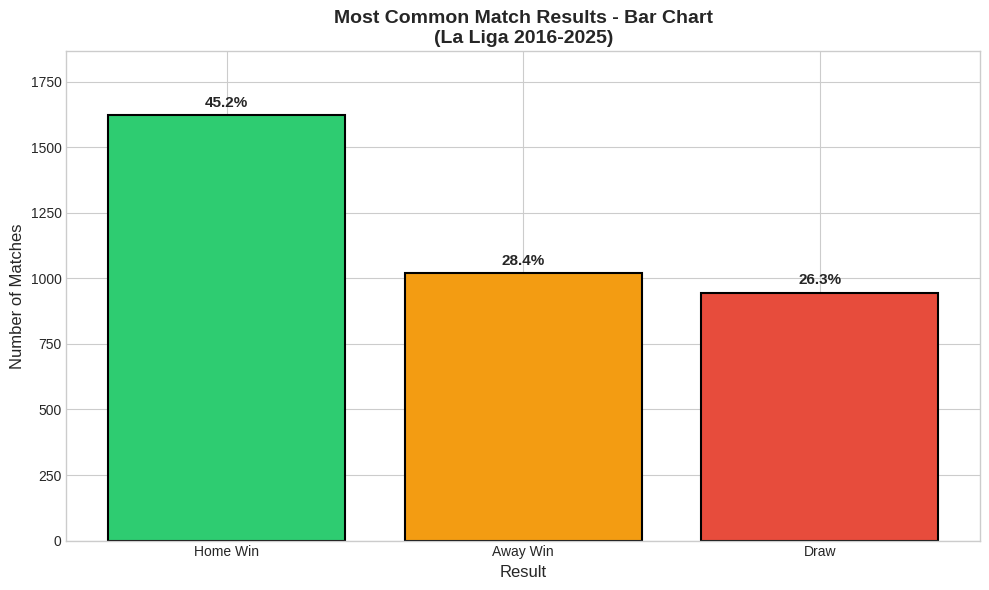

In [48]:
# Bar chart - Most common match results
result_counts = df['full_time_result'].value_counts()
result_labels = {'H': 'Home Win', 'D': 'Draw', 'A': 'Away Win'}
result_percentages = result_counts / len(df) * 100

colors = ['#2ecc71', '#f39c12', '#e74c3c']

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    [result_labels[r] for r in result_counts.index],
    result_counts.values,
    color=colors,
    edgecolor='black',
    linewidth=1.5
)

# Add value labels on bars
for bar, count, pct in zip(bars, result_counts.values, result_percentages.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        f'\n{pct:.1f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax.set_ylabel('Number of Matches', fontsize=12)
ax.set_xlabel('Result', fontsize=12)
ax.set_title('Most Common Match Results - Bar Chart\n(La Liga 2016-2025)', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(result_counts.values) * 1.15)

plt.tight_layout()
plt.show()

We can see the most common result is Home team wins. Followed by Away team wins.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

stats_pairs = [
    ('home_shots', 'away_shots', 'Shots'),
    ('home_shots_on_target', 'away_shots_on_target', 'Shots on Target'),
    ('home_corners', 'away_corners', 'Corners'),
    ('home_yellow_cards', 'away_yellow_cards', 'Yellow Cards')
]

for idx, (home_col, away_col, title) in enumerate(stats_pairs):
    ax = axes[idx // 2, idx % 2]

    # Calcular estadísticas
    home_mean = df[home_col].mean()
    away_mean = df[away_col].mean()

    # Histogramas superpuestos
    max_val = max(df[home_col].max(), df[away_col].max())
    bins = range(0, int(max_val) + 2)

    ax.hist(df[home_col], bins=bins, alpha=0.6, label=f'Home (μ={home_mean:.1f})',
            color='#3498db', edgecolor='black')
    ax.hist(df[away_col], bins=bins, alpha=0.6, label=f'Away (μ={away_mean:.1f})',
            color='#e67e22', edgecolor='black')

    ax.set_xlabel(title, fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{title} Distribution', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

fig.suptitle('Match Statistics: Home vs Away\n(La Liga 2016-2025)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The data confirms a consistent home advantage in attacking metrics (shots, shots on target, corners) while disciplinary stats (yellow cards) remain balanced. Home teams generate roughly more shots and corners than visitors.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

odds_data = [
    df['bet365_home_win_odds'].dropna(),
    df['bet365_draw_odds'].dropna(),
    df['bet365_away_win_odds'].dropna()
]
labels = ['Home Win', 'Draw', 'Away Win']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

bp = ax.boxplot(odds_data, labels=labels, patch_artist=True, notch=True)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Agregar medias como puntos
means = [d.mean() for d in odds_data]
ax.scatter(range(1, 4), means, color='black', marker='D', s=50, zorder=5, label='Mean')


ax.set_ylabel('Odds', fontsize=12)
ax.set_title('Bet365 Odds Distribution by Result Type\n(La Liga 2016-2025)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.set_ylim(0, 15)  # Limitar para mejor visualización

plt.tight_layout()
plt.show()

The data confirms the well-known home field advantage in football, with bookmakers pricing home wins as significantly more likely than away wins on average.

In [ ]:
# Crear columnas de promedio usando las 5 casas de apuestas disponibles
home_odds_cols = ['bet365_home_win_odds', 'betwin_home_win_odds', 'pinnacle_home_win_odds',
                  'william_hill_home_win_odds', 'vcbet_home_win_odds']
draw_odds_cols = ['bet365_draw_odds', 'betwin_draw_odds', 'pinnacle_draw_odds',
                  'william_hill_draw_odds', 'vcbet_draw_odds']
away_odds_cols = ['bet365_away_win_odds', 'betwin_away_win_odds', 'pinnacle_away_win_odds',
                  'william_hill_away_win_odds', 'vcbet_away_win_odds']

df['avg_home_win_odds'] = df[home_odds_cols].mean(axis=1)
df['avg_draw_odds'] = df[draw_odds_cols].mean(axis=1)
df['avg_away_win_odds'] = df[away_odds_cols].mean(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

result_order = ['H', 'D', 'A']
result_labels = {'H': 'Home Win', 'D': 'Draw', 'A': 'Away Win'}
colors = ['#2ecc71', '#f39c12', '#e74c3c']
odds_cols = ['avg_home_win_odds', 'avg_draw_odds', 'avg_away_win_odds']
titles = ['Home Win Odds', 'Draw Odds', 'Away Win Odds']

for idx, (col, title) in enumerate(zip(odds_cols, titles)):
    ax = axes[idx]
    data = [df[df['full_time_result'] == r][col].dropna() for r in result_order]

    bp = ax.boxplot(data, labels=[result_labels[r] for r in result_order],
                    patch_artist=True, notch=True)

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_ylabel(f'Avg {title}', fontsize=11)
    ax.set_xlabel('Actual Result', fontsize=11)
    ax.set_title(f'{title} by Actual Result', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 12)

fig.suptitle('Do Betting Odds Predict Results?\n(La Liga 2016-2025) - Average of 5 Bookmakers', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Análisis: ¿Las cuotas bajas predicen victorias?
print("\nInsight: Betting Odds Analysis (Average of 5 Bookmakers)")
print("-" * 60)
print("Bookmakers: Bet365, BetWin, Pinnacle, William Hill, VCBet\n")
for r, label in result_labels.items():
    subset = df[df['full_time_result'] == r]
    print(f"When result is {label}:")
    print(f"  Avg Home Win Odds: {subset['avg_home_win_odds'].mean():.2f}")
    print(f"  Avg Draw Odds: {subset['avg_draw_odds'].mean():.2f}")
    print(f"  Avg Away Win Odds: {subset['avg_away_win_odds'].mean():.2f}\n")

Bet365 odds demonstrate reasonable predictive power - lower odds correlate with actual outcomes

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calcular métricas por temporada
season_stats = df.groupby('season').agg({
    'full_time_result': lambda x: (x == 'H').mean() * 100,  # % victorias locales
    'full_time_home_goals': 'mean',
    'full_time_away_goals': 'mean'
}).reset_index()

season_stats['total_goals'] = season_stats['full_time_home_goals'] + season_stats['full_time_away_goals']
season_stats.columns = ['Season', 'Home Win %', 'Avg Home Goals', 'Avg Away Goals', 'Avg Total Goals']

# Ordenar temporadas
season_order = sorted(season_stats['Season'].unique())
season_stats['Season'] = pd.Categorical(season_stats['Season'], categories=season_order, ordered=True)
season_stats = season_stats.sort_values('Season')

# Gráfico 1: % Victorias Locales
ax1 = axes[0]
ax1.plot(range(len(season_stats)), season_stats['Home Win %'], marker='o', linewidth=2,
         color='#2ecc71', markersize=8)
ax1.axhline(season_stats['Home Win %'].mean(), color='red', linestyle='--',
            label=f"Average: {season_stats['Home Win %'].mean():.1f}%")
ax1.fill_between(range(len(season_stats)), season_stats['Home Win %'], alpha=0.3, color='#2ecc71')
ax1.set_xticks(range(len(season_stats)))
ax1.set_xticklabels(season_stats['Season'], rotation=45, ha='right')
ax1.set_ylabel('Home Win Percentage (%)', fontsize=11)
ax1.set_title('Home Advantage Over Time', fontsize=12, fontweight='bold')
ax1.legend()
ax1.set_ylim(35, 55)

# Gráfico 2: Goles promedio por partido
ax2 = axes[1]
ax2.plot(range(len(season_stats)), season_stats['Avg Total Goals'], marker='s', linewidth=2,
         color='#3498db', markersize=8, label='Total Goals')
ax2.plot(range(len(season_stats)), season_stats['Avg Home Goals'], marker='^', linewidth=2,
         color='#2ecc71', markersize=6, alpha=0.7, label='Home Goals')
ax2.plot(range(len(season_stats)), season_stats['Avg Away Goals'], marker='v', linewidth=2,
         color='#e74c3c', markersize=6, alpha=0.7, label='Away Goals')
ax2.set_xticks(range(len(season_stats)))
ax2.set_xticklabels(season_stats['Season'], rotation=45, ha='right')
ax2.set_ylabel('Average Goals per Match', fontsize=11)
ax2.set_title('Scoring Trends Over Time', fontsize=12, fontweight='bold')
ax2.legend()

fig.suptitle('La Liga Temporal Analysis (2016-2025)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Average home win rate: 45.3% across all seasons

Peak home advantage: 2022/2023 season (~48%)

Lowest home advantage: 2020/2021 season (~41.5%), notably during COVID-19 when matches were played without fans

Recent trend: Home advantage has recovered post-pandemic, reaching ~47.5% in 2025/2026

On the Scoring trends, we can see that there is a decrease in the total goals per match

In [ ]:

fig, ax = plt.subplots(figsize=(12, 6))

# Calcular valor de mercado promedio por temporada
market_by_season = df.groupby('season').agg({
    'home_total_market_value': 'mean',
    'away_total_market_value': 'mean'
}).reset_index()

market_by_season['avg_market_value'] = (market_by_season['home_total_market_value'] +
                                         market_by_season['away_total_market_value']) / 2

# Ordenar temporadas
season_order = sorted(market_by_season['season'].unique())
market_by_season['season'] = pd.Categorical(market_by_season['season'], categories=season_order, ordered=True)
market_by_season = market_by_season.sort_values('season')

# Gráfico de barras con línea de tendencia
x = range(len(market_by_season))
bars = ax.bar(x, market_by_season['avg_market_value'], color='#9b59b6', alpha=0.7, edgecolor='black')

# Línea de tendencia
z = np.polyfit(x, market_by_season['avg_market_value'], 1)
p = np.poly1d(z)
ax.plot(x, p(x), color='red', linewidth=2, linestyle='--', label=f'Trend')

# Agregar valores sobre las barras
for bar, val in zip(bars, market_by_season['avg_market_value']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{val:.0f}M€',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(market_by_season['season'], rotation=45, ha='right')
ax.set_ylabel('Average Team Market Value (M€)', fontsize=12)
ax.set_xlabel('Season', fontsize=12)
ax.set_title('Football Inflation: Market Value Evolution\n(La Liga 2016-2025)', fontsize=14, fontweight='bold')
ax.legend()

# Calcular crecimiento total
first_val = market_by_season['avg_market_value'].iloc[0]
last_val = market_by_season['avg_market_value'].iloc[-1]
growth = ((last_val - first_val) / first_val) * 100

ax.text(0.02, 0.98, f'Total Growth: {growth:.1f}%\nFrom {first_val:.0f}M€ to {last_val:.0f}M€',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

La Liga team market values grew 38.5% from 2016 to 2025 (€202M → €280M). The peak was in 2018/2019 at €309M. Then, values went down during the covid and have been recovering since 2022/2023.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

# Calcular estadísticas por equipo (combinando home y away)
home_stats = df.groupby('home_team').agg({
    'full_time_result': [
        lambda x: (x == 'H').sum(),  # victorias en casa
        'count'  # partidos en casa
    ]
}).reset_index()
home_stats.columns = ['team', 'home_wins', 'home_matches']

away_stats = df.groupby('away_team').agg({
    'full_time_result': [
        lambda x: (x == 'A').sum(),  # victorias fuera
        'count'  # partidos fuera
    ]
}).reset_index()
away_stats.columns = ['team', 'away_wins', 'away_matches']

# Combinar
team_stats = home_stats.merge(away_stats, on='team')
team_stats['total_wins'] = team_stats['home_wins'] + team_stats['away_wins']
team_stats['total_matches'] = team_stats['home_matches'] + team_stats['away_matches']
team_stats['win_pct'] = team_stats['total_wins'] / team_stats['total_matches'] * 100

# Top 10
top_teams = team_stats.nlargest(10, 'win_pct').sort_values('win_pct')

# Colores degradados
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_teams)))

bars = ax.barh(top_teams['team'], top_teams['win_pct'], color=colors, edgecolor='black')

# Agregar valores
for bar, wins, matches in zip(bars, top_teams['total_wins'], top_teams['total_matches']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}% ({wins}/{matches})',
            va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Win Percentage (%)', fontsize=12)
ax.set_ylabel('Team', fontsize=12)
ax.set_title('Top 10 Teams by Win Percentage\n(La Liga 2016-2025)', fontsize=14, fontweight='bold')
ax.set_xlim(0, max(top_teams['win_pct']) * 1.25)

plt.tight_layout()
plt.show()

This shows what it is expected, Barcelona, Real Madrid, and Ath Madrid are the most winners.

In [ ]:

fig, ax = plt.subplots(figsize=(12, 7))

# Calcular goles por equipo
home_goals = df.groupby('home_team')['full_time_home_goals'].agg(['sum', 'count']).reset_index()
home_goals.columns = ['team', 'home_goals', 'home_matches']

away_goals = df.groupby('away_team')['full_time_away_goals'].agg(['sum', 'count']).reset_index()
away_goals.columns = ['team', 'away_goals', 'away_matches']

# Combinar
goals_stats = home_goals.merge(away_goals, on='team')
goals_stats['total_goals'] = goals_stats['home_goals'] + goals_stats['away_goals']
goals_stats['total_matches'] = goals_stats['home_matches'] + goals_stats['away_matches']
goals_stats['goals_per_match'] = goals_stats['total_goals'] / goals_stats['total_matches']

# Top 10 por goles totales
top_scorers = goals_stats.nlargest(10, 'total_goals').sort_values('total_goals')

# Colores
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(top_scorers)))

bars = ax.barh(top_scorers['team'], top_scorers['total_goals'], color=colors, edgecolor='black')

# Agregar valores
for bar, gpm, matches in zip(bars, top_scorers['goals_per_match'], top_scorers['total_matches']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.0f} goals ({gpm:.2f}/match)',
            va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Total Goals Scored', fontsize=12)
ax.set_ylabel('Team', fontsize=12)
ax.set_title('Top 10 Goal Scoring Teams\n(La Liga 2016-2025)', fontsize=14, fontweight='bold')
ax.set_xlim(0, max(top_scorers['total_goals']) * 1.25)

plt.tight_layout()
plt.show()


This is consistent with the previous chart: The more goals, the more matches you win.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

# Definir las casas de apuestas disponibles
bookmakers = {
    'bet365': ('bet365_home_win_odds', 'bet365_draw_odds', 'bet365_away_win_odds'),
    'betwin': ('betwin_home_win_odds', 'betwin_draw_odds', 'betwin_away_win_odds'),
    'interwetten': ('interwetten_home_win_odds', 'interwetten_draw_odds', 'interwetten_away_win_odds'),
    'ladbrokes': ('ladbrokes_home_win_odds', 'ladbrokes_draw_odds', 'ladbrokes_away_win_odds'),
    'pinnacle': ('pinnacle_home_win_odds', 'pinnacle_draw_odds', 'pinnacle_away_win_odds'),
    'william_hill': ('william_hill_home_win_odds', 'william_hill_draw_odds', 'william_hill_away_win_odds'),
}

# Calcular probabilidades implícitas promedio de TODAS las casas
implied_home_list = []
implied_draw_list = []
implied_away_list = []

for name, (home_col, draw_col, away_col) in bookmakers.items():
    if home_col in df.columns and draw_col in df.columns and away_col in df.columns:
        implied_home_list.append(1 / df[home_col])
        implied_draw_list.append(1 / df[draw_col])
        implied_away_list.append(1 / df[away_col])

# Promedio de todas las casas de apuestas
df['implied_prob_home_avg'] = pd.concat(implied_home_list, axis=1).mean(axis=1)
df['implied_prob_draw_avg'] = pd.concat(implied_draw_list, axis=1).mean(axis=1)
df['implied_prob_away_avg'] = pd.concat(implied_away_list, axis=1).mean(axis=1)

# Probabilidad promedio implícita (todas las casas)
avg_implied = {
    'Home Win': df['implied_prob_home_avg'].mean() * 100,
    'Draw': df['implied_prob_draw_avg'].mean() * 100,
    'Away Win': df['implied_prob_away_avg'].mean() * 100
}

# Frecuencia real de resultados
real_freq = {
    'Home Win': (df['full_time_result'] == 'H').mean() * 100,
    'Draw': (df['full_time_result'] == 'D').mean() * 100,
    'Away Win': (df['full_time_result'] == 'A').mean() * 100
}

# Preparar datos para gráfico
categories = list(avg_implied.keys())
x = np.arange(len(categories))
width = 0.35

# Barras
bars1 = ax.bar(x - width/2, list(avg_implied.values()), width, label='Implied Probability (All Bookmakers Avg)',
               color='#3498db', edgecolor='black', alpha=0.8)
bars2 = ax.bar(x + width/2, list(real_freq.values()), width, label='Actual Frequency',
               color='#e74c3c', edgecolor='black', alpha=0.8)

# Agregar valores sobre las barras
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xlabel('Result Type', fontsize=12)
ax.set_title('Betting Market Efficiency: Implied Probability vs Actual Frequency\n(La Liga 2016-2025, All Bookmakers Average)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend(loc='upper right')
ax.set_ylim(0, 60)

# Calcular overround promedio
overround = sum(avg_implied.values()) - 100
num_bookmakers = len(implied_home_list)
ax.text(0.02, 0.98, f'Avg Bookmaker Margin (Overround): {overround:.1f}%\nBookmakers used: {num_bookmakers}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


Averaging across bookmakers confirms high market efficiency in La Liga. Implied probabilities closely match actual outcomes—home wins (46.8% vs 45.2%), draws (27.0% vs 26.3%), and away wins (31.0% vs 28.4%)

In [ ]:
# Bar chart - Most common exact scorelines
df['scoreline'] = df['full_time_home_goals'].astype(int).astype(str) + '-' + df['full_time_away_goals'].astype(int).astype(str)
scoreline_counts = df['scoreline'].value_counts().head(15)
scoreline_percentages = scoreline_counts / len(df) * 100

fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(scoreline_counts)))

bars = ax.bar(
    scoreline_counts.index,
    scoreline_counts.values,
    color=colors,
    edgecolor='black',
    linewidth=1
)

# Add value labels on bars
for bar, count, pct in zip(bars, scoreline_counts.values, scoreline_percentages.values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        f'{count}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

ax.set_ylabel('Number of Matches', fontsize=12)
ax.set_xlabel('Scoreline (Home - Away)', fontsize=12)
ax.set_title('Top 15 Most Common Exact Scorelines - Bar Chart\n(La Liga 2016-2025)', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(scoreline_counts.values) * 1.2)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

We saw previously that the most common result is :Home win, however, in terms of the most common outcome, 1-1 (draw) is winner.

In [ ]:
# GRÁFICO GEOGRÁFICO: Valor de Mercado de equipos de La Liga en España
import plotly.express as px

# Datos de equipos con sus coordenadas geográficas
team_locations = {
    'Barcelona': {'lat': 41.3809, 'lon': 2.1228, 'city': 'Barcelona'},
    'Real Madrid': {'lat': 40.4530, 'lon': -3.6883, 'city': 'Madrid'},
    'Ath Madrid': {'lat': 40.4361, 'lon': -3.5994, 'city': 'Madrid'},
    'Sevilla': {'lat': 37.3841, 'lon': -5.9706, 'city': 'Sevilla'},
    'Valencia': {'lat': 39.4748, 'lon': -0.3583, 'city': 'Valencia'},
    'Villarreal': {'lat': 39.9439, 'lon': -0.1036, 'city': 'Villarreal'},
    'Ath Bilbao': {'lat': 43.2643, 'lon': -2.9494, 'city': 'Bilbao'},
    'Real Sociedad': {'lat': 43.3017, 'lon': -1.9736, 'city': 'San Sebastián'},
    'Betis': {'lat': 37.3564, 'lon': -5.9817, 'city': 'Sevilla'},
    'Celta': {'lat': 42.2117, 'lon': -8.7397, 'city': 'Vigo'},
    'Getafe': {'lat': 40.3256, 'lon': -3.7146, 'city': 'Getafe'},
    'Osasuna': {'lat': 42.7967, 'lon': -1.6372, 'city': 'Pamplona'},
    'Mallorca': {'lat': 39.5900, 'lon': 2.6300, 'city': 'Palma'},
    'Girona': {'lat': 41.9607, 'lon': 2.8285, 'city': 'Girona'},
    'Alaves': {'lat': 42.8372, 'lon': -2.6883, 'city': 'Vitoria'},
    'Espanol': {'lat': 41.3478, 'lon': 2.0756, 'city': 'Barcelona'},
    'Granada': {'lat': 37.1528, 'lon': -3.5958, 'city': 'Granada'},
    'Leganes': {'lat': 40.3258, 'lon': -3.7558, 'city': 'Leganés'},
    'Rayo Vallecano': {'lat': 40.3917, 'lon': -3.6589, 'city': 'Madrid'},
    'Las Palmas': {'lat': 28.1000, 'lon': -15.4564, 'city': 'Las Palmas'},
    'Valladolid': {'lat': 41.6444, 'lon': -4.7614, 'city': 'Valladolid'},
    'La Coruna': {'lat': 43.3700, 'lon': -8.4100, 'city': 'A Coruña'},
    'Eibar': {'lat': 43.1847, 'lon': -2.4731, 'city': 'Eibar'},
    'Levante': {'lat': 39.4944, 'lon': -0.3653, 'city': 'Valencia'},
    'Huesca': {'lat': 42.1350, 'lon': -0.4083, 'city': 'Huesca'},
    'Cadiz': {'lat': 36.5108, 'lon': -6.2758, 'city': 'Cádiz'},
    'Elche': {'lat': 38.2650, 'lon': -0.7014, 'city': 'Elche'},
    'Almeria': {'lat': 36.8400, 'lon': -2.4637, 'city': 'Almería'},
}

# Calcular valor de mercado promedio por equipo (como local y visitante)
home_market = df.groupby('home_team').agg({
    'home_total_market_value': 'mean',
    'home_avg_market_value': 'mean'
}).reset_index()
home_market.columns = ['team', 'total_market_value', 'avg_player_value']

away_market = df.groupby('away_team').agg({
    'away_total_market_value': 'mean',
    'away_avg_market_value': 'mean'
}).reset_index()
away_market.columns = ['team', 'total_market_value', 'avg_player_value']

# Promediar valores de local y visitante
team_market = home_market.merge(away_market, on='team', suffixes=('_home', '_away'))
team_market['avg_total_market_value'] = (team_market['total_market_value_home'] + team_market['total_market_value_away']) / 2
team_market['avg_player_market_value'] = (team_market['avg_player_value_home'] + team_market['avg_player_value_away']) / 2

# Crear DataFrame para el mapa
map_data = []
for team, coords in team_locations.items():
    stats = team_market[team_market['team'] == team]
    if not stats.empty:
        map_data.append({
            'team': team,
            'lat': coords['lat'],
            'lon': coords['lon'],
            'city': coords['city'],
            'total_market_value': stats['avg_total_market_value'].values[0],
            'avg_player_value': stats['avg_player_market_value'].values[0]
        })

map_df = pd.DataFrame(map_data)

# Crear mapa con scatter_geo
fig = px.scatter_geo(
    map_df,
    lat='lat',
    lon='lon',
    size='total_market_value',
    color='avg_player_value',
    hover_name='team',
    hover_data={
        'city': True,
        'total_market_value': ':.1f',
        'avg_player_value': ':.2f',
        'lat': False,
        'lon': False
    },
    color_continuous_scale='Viridis',
    size_max=50,
    title='Market value per geographic location (2016-2025)',
    labels={
        'total_market_value': 'Total Market Value (M€)',
        'avg_player_value': 'Average Player Value (M€)',
        'city': 'City'
    }
)

# Configurar el mapa centrado en España
fig.update_geos(
    scope='europe',
    center=dict(lat=40.0, lon=-3.5),
    projection_scale=6,
    showland=True,
    landcolor='rgb(243, 243, 243)',
    countrycolor='rgb(204, 204, 204)',
    coastlinecolor='rgb(150, 150, 150)',
    showocean=True,
    oceancolor='rgb(230, 245, 255)',
    showlakes=True,
    lakecolor='rgb(200, 230, 255)',
    showcountries=True
)

fig.update_layout(
    height=700,
    coloraxis_colorbar=dict(
        title='Average Value (M€)',
        tickformat='.1f'
    ),
    title_x=0.5,
    title_font_size=16
)

fig.show()


The visualization reveals a clear concentration of wealth in Madrid and Barcelona

In [ ]:
# Prepare data
df['match_date'] = pd.to_datetime(df['match_date'])
df['month'] = df['match_date'].dt.month
df['month_name'] = df['match_date'].dt.month_name()
df['total_goals'] = df['full_time_home_goals'] + df['full_time_away_goals']

# Función para clasificar estaciones (España)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['calendar_season'] = df['month'].apply(get_season)

# Orden de estaciones para gráficas
season_order = ['Autumn', 'Winter', 'Spring', 'Summer']
df['calendar_season'] = pd.Categorical(df['calendar_season'], categories=season_order, ordered=True)

In [ ]:
fig_box = px.box(
    df,
    x='calendar_season',
    y='total_goals',
    color='calendar_season',
    title='Distribution of Total Goals by Season',
    labels={'calendar_season': 'Season', 'total_goals': 'Total Goals per Match'},
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig_box.update_layout(
    showlegend=False,
    xaxis_title='Season',
    yaxis_title='Total Goals per Match'
)
fig_box.show()

The chart shows that the distribution of goals per match is fairly consistent across all seasons, with a median of 2 goals. Autumn and Winter show slightly more variability. The season of the year does not appear to significantly influence the number of goals per match.

In [ ]:
import pandas as pd
import plotly.express as px

# Load championship data
championships = pd.read_csv('championships.csv')

# Sort by season (from oldest to most recent)
championships = championships.sort_values('Temporada').reset_index(drop=True)

# Normalize club names (some changed names throughout history)
name_mapping = {
    'CF Barcelona': 'FC Barcelona',
    'Madrid Foot-ball Club': 'Real Madrid CF',
    'Athletic-Aviación': 'Atlético de Madrid',
    'Betis Balompié': 'Real Betis'
}
championships['Club'] = championships['Club'].replace(name_mapping)

# Get all unique clubs and years
all_clubs = championships['Club'].unique()
years = sorted(championships['Temporada'].unique())

# Create DataFrame with cumulative championships per year (long format for Plotly)
animation_data = []

for year in years:
    year_data = championships[championships['Temporada'] <= year]
    counts = year_data['Club'].value_counts().to_dict()
    for club in all_clubs:
        animation_data.append({
            'Year': year,
            'Club': club,
            'Championships': counts.get(club, 0)
        })

df_animation = pd.DataFrame(animation_data)

# Official team colors
club_colors = {
    'Real Madrid CF': '#FEBE10',
    'FC Barcelona': '#A50044',
    'Atlético de Madrid': '#CB3524',
    'Athletic Club': '#EE2523',
    'Valencia CF': '#FF7F00',
    'Real Sociedad': '#0067B1',
    'RC Deportivo de La Coruña': '#0055A4',
    'Sevilla FC': '#D4021D',
    'Real Betis': '#00954C'
}

# Create animated Bar Chart Race with Plotly
fig = px.bar(
    df_animation,
    x='Championships',
    y='Club',
    color='Club',
    color_discrete_map=club_colors,
    animation_frame='Year',
    orientation='h',
    range_x=[0, df_animation['Championships'].max() + 2],
    title='Champions of La Liga (1929-2025)',
    labels={'Championships': 'Cumulative Titles', 'Club': ''},
    text='Championships'
)

# Sort bars by value in each frame
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    showlegend=False,
    height=600,
    width=900,
    font=dict(size=12),
    title_font_size=16,
    title_x=0.5
)

# Configure animation
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 100
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 150

# Show values on bars
fig.update_traces(textposition='outside', textfont_size=11)

fig.show()


---
## 6. Feature Engineering for Predictive Models

We will create two types of features:
1. **Pre-Match Features**: Rolling statistics from the last 5 matches for each team
2. **In-Play Features**: Half-time data for live predictions

In [ ]:
# Ensure match_date is datetime and sort by date
df['match_date'] = pd.to_datetime(df['match_date'], dayfirst=True)
df = df.sort_values('match_date').reset_index(drop=True)

# Create target variable (numeric encoding)
target_map = {'H': 0, 'D': 1, 'A': 2}
df['target'] = df['full_time_result'].map(target_map)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['match_date'].min()} to {df['match_date'].max()}")
print(f"\nTarget distribution:")
print(df['full_time_result'].value_counts(normalize=True).round(3))

### 6.1 Pre-Match Features: Rolling Statistics (Last 5 Matches)

For each team, we calculate statistics from their last 5 matches (regardless of home/away).

In [ ]:
def calculate_team_rolling_stats(df, window=5):
    """
    Calculate rolling statistics for each team based on their last N matches.
    Returns a dictionary with team stats at each match date.
    Now includes: red cards and half-time goals averages.
    """
    # Create a unified view of all matches from each team's perspective
    home_matches = df[['match_date', 'home_team', 'full_time_home_goals', 'full_time_away_goals',
                       'home_shots', 'home_shots_on_target', 'home_corners',
                       'home_yellow_cards', 'home_red_cards', 'half_time_home_goals', 'full_time_result']].copy()
    home_matches.columns = ['date', 'team', 'goals_scored', 'goals_conceded',
                           'shots', 'shots_on_target', 'corners',
                           'yellow_cards', 'red_cards', 'ht_goals_scored', 'result']
    home_matches['is_home'] = 1
    home_matches['points'] = home_matches['result'].map({'H': 3, 'D': 1, 'A': 0})
    home_matches['win'] = (home_matches['result'] == 'H').astype(int)

    away_matches = df[['match_date', 'away_team', 'full_time_away_goals', 'full_time_home_goals',
                       'away_shots', 'away_shots_on_target', 'away_corners',
                       'away_yellow_cards', 'away_red_cards', 'half_time_away_goals', 'full_time_result']].copy()
    away_matches.columns = ['date', 'team', 'goals_scored', 'goals_conceded',
                           'shots', 'shots_on_target', 'corners',
                           'yellow_cards', 'red_cards', 'ht_goals_scored', 'result']
    away_matches['is_home'] = 0
    away_matches['points'] = away_matches['result'].map({'H': 0, 'D': 1, 'A': 3})
    away_matches['win'] = (away_matches['result'] == 'A').astype(int)

    # Combine all matches
    all_matches = pd.concat([home_matches, away_matches], ignore_index=True)
    all_matches = all_matches.sort_values(['team', 'date']).reset_index(drop=True)

    # Calculate rolling stats for each team
    team_stats = {}

    for team in all_matches['team'].unique():
        team_data = all_matches[all_matches['team'] == team].copy()
        team_data = team_data.sort_values('date')

        # Calculate rolling averages (shift to avoid data leakage - don't include current match)
        # Original stats
        for col in ['goals_scored', 'goals_conceded', 'shots', 'shots_on_target',
                    'corners', 'yellow_cards', 'points', 'win']:
            team_data[f'{col}_avg_{window}'] = team_data[col].shift(1).rolling(window=window, min_periods=1).mean()

        # NEW: Red cards and half-time goals averages
        team_data[f'red_cards_avg_{window}'] = team_data['red_cards'].shift(1).rolling(window=window, min_periods=1).mean()
        team_data[f'ht_goals_scored_avg_{window}'] = team_data['ht_goals_scored'].shift(1).rolling(window=window, min_periods=1).mean()

        # Store stats indexed by date
        for _, row in team_data.iterrows():
            key = (team, row['date'])
            team_stats[key] = {
                f'goals_scored_avg_{window}': row[f'goals_scored_avg_{window}'],
                f'goals_conceded_avg_{window}': row[f'goals_conceded_avg_{window}'],
                f'shots_avg_{window}': row[f'shots_avg_{window}'],
                f'shots_on_target_avg_{window}': row[f'shots_on_target_avg_{window}'],
                f'corners_avg_{window}': row[f'corners_avg_{window}'],
                f'yellow_cards_avg_{window}': row[f'yellow_cards_avg_{window}'],
                f'points_avg_{window}': row[f'points_avg_{window}'],
                f'win_rate_{window}': row[f'win_avg_{window}'],
                # NEW stats
                f'red_cards_avg_{window}': row[f'red_cards_avg_{window}'],
                f'ht_goals_scored_avg_{window}': row[f'ht_goals_scored_avg_{window}'],
            }

    return team_stats

# Calculate rolling stats
print("Calculating rolling statistics...")
team_stats = calculate_team_rolling_stats(df, window=5)
print(f"Computed stats for {len(set(k[0] for k in team_stats.keys()))} teams")

In [ ]:
# Apply rolling stats to the main dataframe
def apply_team_stats(row, team_stats, prefix, team_col):
    """Apply pre-computed team stats to a row."""
    team = row[team_col]
    date = row['match_date']
    key = (team, date)

    if key in team_stats:
        stats = team_stats[key]
        return pd.Series({f'{prefix}_{k}': v for k, v in stats.items()})
    else:
        return pd.Series({f'{prefix}_{k}': np.nan for k in [
            'goals_scored_avg_5', 'goals_conceded_avg_5', 'shots_avg_5',
            'shots_on_target_avg_5', 'corners_avg_5', 'yellow_cards_avg_5',
            'points_avg_5', 'win_rate_5',
            # NEW stats
            'red_cards_avg_5', 'ht_goals_scored_avg_5'
        ]})

# Apply for home team
print("Applying rolling stats for home teams...")
home_stats = df.apply(lambda row: apply_team_stats(row, team_stats, 'home', 'home_team'), axis=1)
df = pd.concat([df, home_stats], axis=1)

# Apply for away team
print("Applying rolling stats for away teams...")
away_stats = df.apply(lambda row: apply_team_stats(row, team_stats, 'away', 'away_team'), axis=1)
df = pd.concat([df, away_stats], axis=1)

print("Rolling stats applied successfully!")
print(f"New columns added: {[c for c in df.columns if 'avg_5' in c or 'rate_5' in c]}")

In [ ]:
# Create additional derived features
# Market value ratio (home vs away)
df['market_value_ratio'] = df['home_total_market_value'] / (df['away_total_market_value'])

# Form difference (home advantage in recent form)
df['form_diff'] = df['home_points_avg_5'] - df['away_points_avg_5']
df['goals_scored_diff'] = df['home_goals_scored_avg_5'] - df['away_goals_scored_avg_5']
df['goals_conceded_diff'] = df['home_goals_conceded_avg_5'] - df['away_goals_conceded_avg_5']

# NEW: Additional difference features
df['shots_diff'] = df['home_shots_avg_5'] - df['away_shots_avg_5']
df['shots_on_target_diff'] = df['home_shots_on_target_avg_5'] - df['away_shots_on_target_avg_5']
df['corners_diff'] = df['home_corners_avg_5'] - df['away_corners_avg_5']
df['yellow_cards_diff'] = df['home_yellow_cards_avg_5'] - df['away_yellow_cards_avg_5']
df['red_cards_diff_avg'] = df['home_red_cards_avg_5'] - df['away_red_cards_avg_5']
df['ht_goals_diff_avg'] = df['home_ht_goals_scored_avg_5'] - df['away_ht_goals_scored_avg_5']

# NEW: Efficiency ratios (shot conversion and accuracy)
df['home_shot_conversion'] = df['home_goals_scored_avg_5'] / df['home_shots_avg_5'].replace(0, np.nan)
df['away_shot_conversion'] = df['away_goals_scored_avg_5'] / df['away_shots_avg_5'].replace(0, np.nan)
df['home_shot_accuracy'] = df['home_shots_on_target_avg_5'] / df['home_shots_avg_5'].replace(0, np.nan)
df['away_shot_accuracy'] = df['away_shots_on_target_avg_5'] / df['away_shots_avg_5'].replace(0, np.nan)

# Fill NaN with median for efficiency ratios
for col in ['home_shot_conversion', 'away_shot_conversion', 'home_shot_accuracy', 'away_shot_accuracy']:
    df[col] = df[col].fillna(df[col].median())

# Implied probabilities from betting odds (using average of ALL bookmakers)
# List of all available bookmakers
bookmakers_home = ['bet365_home_win_odds', 'betwin_home_win_odds', 'interwetten_home_win_odds',
                   'ladbrokes_home_win_odds', 'pinnacle_home_win_odds', 'william_hill_home_win_odds',
                   'vcbet_home_win_odds']
bookmakers_draw = ['bet365_draw_odds', 'betwin_draw_odds', 'interwetten_draw_odds',
                   'ladbrokes_draw_odds', 'pinnacle_draw_odds', 'william_hill_draw_odds',
                   'vcbet_draw_odds']
bookmakers_away = ['bet365_away_win_odds', 'betwin_away_win_odds', 'interwetten_away_win_odds',
                   'ladbrokes_away_win_odds', 'pinnacle_away_win_odds', 'william_hill_away_win_odds',
                   'vcbet_away_win_odds']

# Filter to only existing columns
bookmakers_home = [col for col in bookmakers_home if col in df.columns]
bookmakers_draw = [col for col in bookmakers_draw if col in df.columns]
bookmakers_away = [col for col in bookmakers_away if col in df.columns]

# Calculate average odds across all bookmakers
df['avg_home_odds'] = df[bookmakers_home].mean(axis=1)
df['avg_draw_odds'] = df[bookmakers_draw].mean(axis=1)
df['avg_away_odds'] = df[bookmakers_away].mean(axis=1)

# Convert average odds to implied probabilities
df['implied_prob_home'] = 1 / df['avg_home_odds']
df['implied_prob_draw'] = 1 / df['avg_draw_odds']
df['implied_prob_away'] = 1 / df['avg_away_odds']

print(f"Using average odds from {len(bookmakers_home)} bookmakers:")
print(f"  {', '.join([b.split('_')[0] for b in bookmakers_home])}")

# Normalize implied probabilities (remove overround)
total_implied = df['implied_prob_home'] + df['implied_prob_draw'] + df['implied_prob_away']
df['implied_prob_home_norm'] = df['implied_prob_home'] / total_implied
df['implied_prob_draw_norm'] = df['implied_prob_draw'] / total_implied
df['implied_prob_away_norm'] = df['implied_prob_away'] / total_implied

print("\nAdditional features created:")
print("- market_value_ratio")
print("- form_diff, goals_scored_diff, goals_conceded_diff")
print("- NEW: shots_diff, shots_on_target_diff, corners_diff, yellow_cards_diff, red_cards_diff_avg, ht_goals_diff_avg")
print("- NEW: home/away_shot_conversion, home/away_shot_accuracy")
print("- implied_prob_home/draw/away (normalized from average odds)")

# === DRAW-SPECIFIC FEATURES ===
# Calculate rolling draw rate for each team (as home and away)

def calculate_draw_rate_rolling(df, team_col, result_col='full_time_result', window=5):
    """Calculate rolling draw rate for a team in their matches"""
    draw_rates = []
    for team in df[team_col].unique():
        team_matches = df[df[team_col] == team].copy()
        team_matches = team_matches.sort_values('match_date')
        draws = (team_matches[result_col] == 'D').astype(int)
        team_matches['draw_rate'] = draws.rolling(window=window, min_periods=1).mean().shift(1)
        draw_rates.append(team_matches[['match_date', team_col, 'draw_rate']])
    return pd.concat(draw_rates)

# Calculate draw rates for home teams
home_draw_rates = calculate_draw_rate_rolling(df, 'home_team')
home_draw_rates = home_draw_rates.rename(columns={'draw_rate': 'home_draw_rate_5'})
df = df.merge(home_draw_rates[['match_date', 'home_team', 'home_draw_rate_5']],
              on=['match_date', 'home_team'], how='left')

# Calculate draw rates for away teams
away_draw_rates = calculate_draw_rate_rolling(df, 'away_team')
away_draw_rates = away_draw_rates.rename(columns={'draw_rate': 'away_draw_rate_5'})
df = df.merge(away_draw_rates[['match_date', 'away_team', 'away_draw_rate_5']],
              on=['match_date', 'away_team'], how='left')

# Combined draw tendency (average of both teams' draw rates)
df['combined_draw_tendency'] = (df['home_draw_rate_5'].fillna(0) + df['away_draw_rate_5'].fillna(0)) / 2

# Fill NaN with league average draw rate (~0.26)
df['home_draw_rate_5'] = df['home_draw_rate_5'].fillna(0.26)
df['away_draw_rate_5'] = df['away_draw_rate_5'].fillna(0.26)
df['combined_draw_tendency'] = df['combined_draw_tendency'].fillna(0.26)

print("\n=== DRAW-SPECIFIC FEATURES ADDED ===")
print("- home_draw_rate_5: Rolling draw rate for home team (last 5 home matches)")
print("- away_draw_rate_5: Rolling draw rate for away team (last 5 away matches)")
print("- combined_draw_tendency: Average of both teams' draw rates")

### 6.2 In-Play Features (Half-Time Data)

Features available at half-time for live predictions.

In [ ]:
# In-Play features (data available at half-time)
# Goal difference at half-time
df['ht_goal_diff'] = df['half_time_home_goals'] - df['half_time_away_goals']
df['ht_total_goals'] = df['half_time_home_goals'] + df['half_time_away_goals']

# Encode half-time result
ht_result_map = {'H': 1, 'D': 0, 'A': -1}
df['ht_result_encoded'] = df['half_time_result'].map(ht_result_map)

# Cards difference at half-time (approximation - we use total cards, which is end of match)
# In real scenario you'd have HT card data, but we'll use what we have
df['cards_diff'] = df['home_yellow_cards'] - df['away_yellow_cards']
df['has_red_card_home'] = (df['home_red_cards'] > 0).astype(int)
df['has_red_card_away'] = (df['away_red_cards'] > 0).astype(int)
df['red_card_diff'] = df['home_red_cards'] - df['away_red_cards']

print("In-Play features created:")
print("- ht_goal_diff, ht_total_goals")
print("- ht_result_encoded")
print("- cards_diff, has_red_card_home/away, red_card_diff")

---
## 7. Model Training

### 7.1 Data Preparation and Train/Test Split

In [ ]:
!pip install optuna

In [ ]:

# Import ML libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss, classification_report, confusion_matrix
import xgboost as xgb
import lightgbm as lgb

# Optuna for hyperparameter optimization
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
# Define feature lists for models

# Create Label Encoders for team names
le_home = LabelEncoder()
le_away = LabelEncoder()

# Fit encoders on all teams (combining home and away to ensure consistent encoding)
all_teams = pd.concat([df['home_team'], df['away_team']]).unique()
le_home.fit(all_teams)
le_away.fit(all_teams)

# Create encoded columns
df['home_team_encoded'] = le_home.transform(df['home_team'])
df['away_team_encoded'] = le_away.transform(df['away_team'])

print(f"Teams encoded: {len(all_teams)} unique teams")
print(f"Team mapping example: {dict(zip(le_home.classes_[:5], range(5)))}")

# PRE-MATCH FEATURES (available before the match)
pre_match_features = [
    # Team identity (encoded)
    'home_team_encoded', 'away_team_encoded',
    # Rolling stats - Home team, away team
    'home_goals_scored_avg_5', 'home_goals_conceded_avg_5',
    'home_shots_avg_5', 'home_shots_on_target_avg_5',
    'home_corners_avg_5', 'home_yellow_cards_avg_5',
    'home_points_avg_5', 'home_win_rate_5',
    'home_red_cards_avg_5', 'home_ht_goals_scored_avg_5',
    'away_goals_scored_avg_5', 'away_goals_conceded_avg_5',
    'away_shots_avg_5', 'away_shots_on_target_avg_5',
    'away_corners_avg_5', 'away_yellow_cards_avg_5',
    'away_points_avg_5', 'away_win_rate_5',
    'away_red_cards_avg_5', 'away_ht_goals_scored_avg_5',
    # Derived features (original)
    'market_value_ratio', 'form_diff', 'goals_scored_diff', 'goals_conceded_diff',
    'shots_diff', 'shots_on_target_diff', 'corners_diff',
    'yellow_cards_diff', 'red_cards_diff_avg', 'ht_goals_diff_avg',
    # NEW: Efficiency ratios
    'home_shot_conversion', 'away_shot_conversion',
    'home_shot_accuracy', 'away_shot_accuracy',
    # Betting odds (implied probabilities)
    'implied_prob_home_norm', 'implied_prob_draw_norm', 'implied_prob_away_norm',
    # Market values
    'home_total_market_value', 'away_total_market_value',
    # Draw-specific features
    'home_draw_rate_5', 'away_draw_rate_5'
]

# IN-PLAY FEATURES (available at half-time)
in_play_features = pre_match_features + [
    # Half-time data
    'half_time_home_goals', 'half_time_away_goals',
    'ht_goal_diff', 'ht_total_goals', 'ht_result_encoded',
    # Cards (note: using end-of-match data as proxy)
    'cards_diff', 'has_red_card_home', 'has_red_card_away', 'red_card_diff'
]

# remove home_team_encoded and away_team_encoded from in_play (not good for in-play because we tested it)
in_play_features.remove('home_team_encoded')
in_play_features.remove('away_team_encoded')

print(f"\nPre-match features: {len(pre_match_features)}")
print(f"In-play features: {len(in_play_features)}")
print(f"\nNEW features added:")
print("  - Rolling: home/away_red_cards_avg_5, home/away_ht_goals_scored_avg_5")
print("  - Derived: shots_diff, shots_on_target_diff, corners_diff, yellow_cards_diff, red_cards_diff_avg, ht_goals_diff_avg")
print("  - Efficiency: home/away_shot_conversion, home/away_shot_accuracy")
print("  - Draw-specific: home_draw_rate_5, away_draw_rate_5, combined_draw_tendency")

In [ ]:
# Temporal split: Train (2016-2023), Test (2024-2025)
# Extract year from season (e.g., "2016/2017" -> 2016)
df['season_year'] = df['season'].str.split('/').str[0].astype(int)

# Split data
train_mask = df['season_year'] <= 2024
test_mask = df['season_year'] >= 2025

# Remove rows with too many missing values in features
def prepare_dataset(df_subset, features):
    """Prepare dataset by removing rows with missing values in key features."""
    df_clean = df_subset.dropna(subset=features + ['target'])
    X = df_clean[features].copy()
    y = df_clean['target'].copy()
    return X, y, df_clean

# Prepare pre-match datasets
X_train_pre, y_train_pre, df_train_pre = prepare_dataset(df[train_mask], pre_match_features)
X_test_pre, y_test_pre, df_test_pre = prepare_dataset(df[test_mask], pre_match_features)

# Prepare in-play datasets
X_train_inplay, y_train_inplay, df_train_inplay = prepare_dataset(df[train_mask], in_play_features)
X_test_inplay, y_test_inplay, df_test_inplay = prepare_dataset(df[test_mask], in_play_features)

print("=== PRE-MATCH MODEL ===")
print(f"Training set: {len(X_train_pre)} matches")
print(f"Test set: {len(X_test_pre)} matches")
print(f"\nTarget distribution (train): {y_train_pre.value_counts(normalize=True).round(3).to_dict()}")
print(f"Target distribution (test): {y_test_pre.value_counts(normalize=True).round(3).to_dict()}")

print("\n=== IN-PLAY MODEL ===")
print(f"Training set: {len(X_train_inplay)} matches")
print(f"Test set: {len(X_test_inplay)} matches")

### 7.2 Pre-Match Model Training

Training Random Forest, XGBoost, and LightGBM models to predict match outcomes before kick-off.

In [40]:
# Import for class weighting in XGBoost
from sklearn.utils.class_weight import compute_sample_weight

# Scale features for better model performance
scaler_pre = StandardScaler()
X_train_pre_scaled = scaler_pre.fit_transform(X_train_pre)
X_test_pre_scaled = scaler_pre.transform(X_test_pre)

# Optuna configuration
N_TRIALS = 50
CV_FOLDS = 3

# Define objective functions for Optuna
def objective_rf(trial, X, y):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
    }
    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1, class_weight='balanced')
    scores = cross_val_score(model, X, y, cv=CV_FOLDS, scoring='f1_weighted')
    return scores.mean()

def objective_xgb(trial, X, y):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }
    model = xgb.XGBClassifier(**params, random_state=42, eval_metric='mlogloss', verbosity=0)
    scores = cross_val_score(model, X, y, cv=CV_FOLDS, scoring='f1_weighted')
    return scores.mean()

def objective_lgb(trial, X, y):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
    }
    model = lgb.LGBMClassifier(**params, random_state=42, verbose=-1, class_weight='balanced')
    scores = cross_val_score(model, X, y, cv=CV_FOLDS, scoring='f1_weighted')
    return scores.mean()

# Train models and store results
pre_match_models = {}
pre_match_results = {}

# 1. Random Forest with Optuna
print("Optimizing Random Forest (Pre-Match)...")
study_rf_pre = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_rf_pre.optimize(lambda trial: objective_rf(trial, X_train_pre_scaled, y_train_pre),
                      n_trials=N_TRIALS, show_progress_bar=True)
print(f"Best RF params: {study_rf_pre.best_params}")
rf_pre = RandomForestClassifier(**study_rf_pre.best_params, random_state=42, n_jobs=-1, class_weight='balanced')
rf_pre.fit(X_train_pre_scaled, y_train_pre)
pre_match_models['Random Forest'] = rf_pre

# 2. XGBoost with Optuna
print("\nOptimizing XGBoost (Pre-Match)...")
study_xgb_pre = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
# Compute sample weights for balanced training (used in final fit)
sample_weights_train = compute_sample_weight('balanced', y_train_pre)
study_xgb_pre.optimize(lambda trial: objective_xgb(trial, X_train_pre_scaled, y_train_pre),
                       n_trials=N_TRIALS, show_progress_bar=True)
print(f"Best XGB params: {study_xgb_pre.best_params}")
xgb_pre = xgb.XGBClassifier(**study_xgb_pre.best_params, random_state=42, eval_metric='mlogloss', verbosity=0)
xgb_pre.fit(X_train_pre_scaled, y_train_pre, sample_weight=sample_weights_train)
pre_match_models['XGBoost'] = xgb_pre

# 3. LightGBM with Optuna
print("\nOptimizing LightGBM (Pre-Match)...")
study_lgb_pre = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_lgb_pre.optimize(lambda trial: objective_lgb(trial, X_train_pre_scaled, y_train_pre),
                       n_trials=N_TRIALS, show_progress_bar=True)
print(f"Best LGB params: {study_lgb_pre.best_params}")
lgb_pre = lgb.LGBMClassifier(**study_lgb_pre.best_params, random_state=42, verbose=-1, class_weight='balanced')
lgb_pre.fit(X_train_pre_scaled, y_train_pre)
pre_match_models['LightGBM'] = lgb_pre

print("\nAll Pre-Match models optimized and trained successfully!")

Optimizing Random Forest (Pre-Match)...


  0%|          | 0/50 [00:00<?, ?it/s]

Best RF params: {'n_estimators': 213, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 5}

Optimizing XGBoost (Pre-Match)...


  0%|          | 0/50 [00:00<?, ?it/s]

[W 2026-01-21 16:57:35,711] Trial 18 failed with parameters: {'n_estimators': 403, 'max_depth': 6, 'learning_rate': 0.050793314871402755, 'subsample': 0.7707452224731817, 'colsample_bytree': 0.7242757678791987, 'reg_alpha': 0.001087784929992828, 'reg_lambda': 0.9827502346473642} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipython-input-616869316.py", line 73, in <lambda>
    study_xgb_pre.optimize(lambda trial: objective_xgb(trial, X_train_pre_scaled, y_train_pre),
                                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-616869316.py", line 36, in objective_xgb
    scores = cross_val_score(model, X, y, cv=CV_FOLDS, scoring='f1_weighted')
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

KeyboardInterrupt: 

In [ ]:
# Evaluate Pre-Match models
print("=" * 60)
print("PRE-MATCH MODEL EVALUATION")
print("=" * 60)

target_names = ['Home Win (H)', 'Draw (D)', 'Away Win (A)']

from sklearn.metrics import f1_score

for name, model in pre_match_models.items():
    print(f"\n{'='*20} {name} {'='*20}")

    # Get predictions
    y_pred = model.predict(X_test_pre_scaled)
    y_prob = model.predict_proba(X_test_pre_scaled)

    # Calculate metrics
    accuracy = accuracy_score(y_test_pre, y_pred)
    logloss = log_loss(y_test_pre, y_prob)
    f1_weighted = f1_score(y_test_pre, y_pred, average='weighted')
    f1_macro = f1_score(y_test_pre, y_pred, average='macro')

    pre_match_results[name] = {
        'accuracy': accuracy,
        'log_loss': logloss,
        'f1_weighted': f1_weighted,
        'f1_macro': f1_macro,
        'predictions': y_pred,
        'probabilities': y_prob
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Log Loss: {logloss:.4f}")
    print(f"F1 Score (Weighted): {f1_weighted:.4f}")
    print(f"F1 Score (Macro): {f1_macro:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test_pre, y_pred, target_names=target_names))

# Baseline comparison (always predict home win)
baseline_accuracy = (y_test_pre == 0).mean()
print(f"\n{'='*60}")
print(f"BASELINE (always predict Home Win): {baseline_accuracy:.4f}")
print(f"{'='*60}")

### 7.3 In-Play Model Training (Half-Time)

Training models that use half-time data to predict the final result.

In [ ]:
# Scale features for in-play models
scaler_inplay = StandardScaler()
X_train_inplay_scaled = scaler_inplay.fit_transform(X_train_inplay)
X_test_inplay_scaled = scaler_inplay.transform(X_test_inplay)

# Train in-play models with Optuna optimization
inplay_models = {}
inplay_results = {}

# 1. Random Forest with Optuna
print("Optimizing Random Forest (In-Play)...")
study_rf_inplay = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_rf_inplay.optimize(lambda trial: objective_rf(trial, X_train_inplay_scaled, y_train_inplay),
                         n_trials=N_TRIALS, show_progress_bar=True)
print(f"Best RF params: {study_rf_inplay.best_params}")
rf_inplay = RandomForestClassifier(**study_rf_inplay.best_params, random_state=42, n_jobs=-1, class_weight='balanced')
rf_inplay.fit(X_train_inplay_scaled, y_train_inplay)
inplay_models['Random Forest'] = rf_inplay

# 2. XGBoost with Optuna
print("\nOptimizing XGBoost (In-Play)...")
study_xgb_inplay = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
# Compute sample weights for balanced training (used in final fit)
sample_weights_inplay = compute_sample_weight('balanced', y_train_inplay)
study_xgb_inplay.optimize(lambda trial: objective_xgb(trial, X_train_inplay_scaled, y_train_inplay),
                          n_trials=N_TRIALS, show_progress_bar=True)
print(f"Best XGB params: {study_xgb_inplay.best_params}")
xgb_inplay = xgb.XGBClassifier(**study_xgb_inplay.best_params, random_state=42, eval_metric='mlogloss', verbosity=0)
xgb_inplay.fit(X_train_inplay_scaled, y_train_inplay, sample_weight=sample_weights_inplay)
inplay_models['XGBoost'] = xgb_inplay

# 3. LightGBM with Optuna
print("\nOptimizing LightGBM (In-Play)...")
study_lgb_inplay = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_lgb_inplay.optimize(lambda trial: objective_lgb(trial, X_train_inplay_scaled, y_train_inplay),
                          n_trials=N_TRIALS, show_progress_bar=True)
print(f"Best LGB params: {study_lgb_inplay.best_params}")
lgb_inplay = lgb.LGBMClassifier(**study_lgb_inplay.best_params, random_state=42, verbose=-1, class_weight='balanced')
lgb_inplay.fit(X_train_inplay_scaled, y_train_inplay)
inplay_models['LightGBM'] = lgb_inplay

print("\nAll In-Play models optimized and trained successfully!")

In [ ]:
# Evaluate In-Play models
print("=" * 60)
print("IN-PLAY MODEL EVALUATION (Half-Time Data)")
print("=" * 60)

for name, model in inplay_models.items():
    print(f"\n{'='*20} {name} {'='*20}")

    # Get predictions
    y_pred = model.predict(X_test_inplay_scaled)
    y_prob = model.predict_proba(X_test_inplay_scaled)

    # Calculate metrics
    accuracy = accuracy_score(y_test_inplay, y_pred)
    logloss = log_loss(y_test_inplay, y_prob)
    f1_weighted = f1_score(y_test_inplay, y_pred, average='weighted')
    f1_macro = f1_score(y_test_inplay, y_pred, average='macro')

    inplay_results[name] = {
        'accuracy': accuracy,
        'log_loss': logloss,
        'f1_weighted': f1_weighted,
        'f1_macro': f1_macro,
        'predictions': y_pred,
        'probabilities': y_prob
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Log Loss: {logloss:.4f}")
    print(f"F1 Score (Weighted): {f1_weighted:.4f}")
    print(f"F1 Score (Macro): {f1_macro:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test_inplay, y_pred, target_names=target_names))

### 7.4 Model Comparison

In [ ]:
# Create comparison DataFrame
comparison_data = []

for name in ['Random Forest', 'XGBoost', 'LightGBM']:
    comparison_data.append({
        'Model': name,
        'Type': 'Pre-Match',
        'Accuracy': pre_match_results[name]['accuracy'],
        'Log Loss': pre_match_results[name]['log_loss'],
        'F1 (Weighted)': pre_match_results[name]['f1_weighted'],
        'F1 (Macro)': pre_match_results[name]['f1_macro']
    })
    comparison_data.append({
        'Model': name,
        'Type': 'In-Play (HT)',
        'Accuracy': inplay_results[name]['accuracy'],
        'Log Loss': inplay_results[name]['log_loss'],
        'F1 (Weighted)': inplay_results[name]['f1_weighted'],
        'F1 (Macro)': inplay_results[name]['f1_macro']
    })

comparison_df = pd.DataFrame(comparison_data)

# Display comparison
print("=" * 90)
print("MODEL COMPARISON SUMMARY")
print("=" * 90)
print(comparison_df.to_string(index=False))

# Identify best models by different metrics
best_pre_acc = comparison_df[comparison_df['Type'] == 'Pre-Match'].loc[
    comparison_df[comparison_df['Type'] == 'Pre-Match']['Accuracy'].idxmax()
]
best_inplay_acc = comparison_df[comparison_df['Type'] == 'In-Play (HT)'].loc[
    comparison_df[comparison_df['Type'] == 'In-Play (HT)']['Accuracy'].idxmax()
]
best_pre_f1 = comparison_df[comparison_df['Type'] == 'Pre-Match'].loc[
    comparison_df[comparison_df['Type'] == 'Pre-Match']['F1 (Weighted)'].idxmax()
]
best_inplay_f1 = comparison_df[comparison_df['Type'] == 'In-Play (HT)'].loc[
    comparison_df[comparison_df['Type'] == 'In-Play (HT)']['F1 (Weighted)'].idxmax()
]

print(f"\n{'='*90}")
print("BEST MODELS BY ACCURACY:")
print(f"  Pre-Match: {best_pre_acc['Model']} (Accuracy: {best_pre_acc['Accuracy']:.4f})")
print(f"  In-Play:   {best_inplay_acc['Model']} (Accuracy: {best_inplay_acc['Accuracy']:.4f})")
print(f"\nBEST MODELS BY F1 SCORE (Weighted):")
print(f"  Pre-Match: {best_pre_f1['Model']} (F1: {best_pre_f1['F1 (Weighted)']:.4f})")
print(f"  In-Play:   {best_inplay_f1['Model']} (F1: {best_inplay_f1['F1 (Weighted)']:.4f})")
print(f"{'='*90}")

In [ ]:
# Visualization: Model Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy comparison
ax1 = axes[0]
pivot_acc = comparison_df.pivot(index='Model', columns='Type', values='Accuracy')
pivot_acc.plot(kind='bar', ax=ax1, color=['#3498db', '#e74c3c'])
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Model')
ax1.set_ylim(0, 1)
ax1.legend(title='Model Type')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# Add value labels
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.3f', fontsize=9)

# Log Loss comparison
ax2 = axes[1]
pivot_ll = comparison_df.pivot(index='Model', columns='Type', values='Log Loss')
pivot_ll.plot(kind='bar', ax=ax2, color=['#3498db', '#e74c3c'])
ax2.set_title('Model Log Loss Comparison (lower is better)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Log Loss')
ax2.set_xlabel('Model')
ax2.legend(title='Model Type')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

# Add value labels
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.3f', fontsize=9)

# F1 Score comparison (NEW)
ax3 = axes[2]
pivot_f1 = comparison_df.pivot(index='Model', columns='Type', values='F1 (Weighted)')
pivot_f1.plot(kind='bar', ax=ax3, color=['#3498db', '#e74c3c'])
ax3.set_title('Model F1 Score Comparison (Weighted)', fontsize=14, fontweight='bold')
ax3.set_ylabel('F1 Score')
ax3.set_xlabel('Model')
ax3.set_ylim(0, 1)
ax3.legend(title='Model Type')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)

# Add value labels
for container in ax3.containers:
    ax3.bar_label(container, fmt='%.3f', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Feature Importance (using best model - LightGBM as example)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Pre-Match Feature Importance
ax1 = axes[0]
importance_pre = pd.DataFrame({
    'feature': pre_match_features,
    'importance': lgb_pre.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

ax1.barh(importance_pre['feature'], importance_pre['importance'], color='#3498db')
ax1.set_title('Pre-Match Model - Top 15 Features', fontsize=14, fontweight='bold')
ax1.set_xlabel('Importance')

# In-Play Feature Importance
ax2 = axes[1]
importance_inplay = pd.DataFrame({
    'feature': in_play_features,
    'importance': lgb_inplay.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

ax2.barh(importance_inplay['feature'], importance_inplay['importance'], color='#e74c3c')
ax2.set_title('In-Play Model - Top 15 Features', fontsize=14, fontweight='bold')
ax2.set_xlabel('Importance')

plt.tight_layout()
plt.show()